In [1]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:46477")
client

<Client: 'tcp://127.0.0.1:46477' processes=6 threads=48, memory=48.00 GiB>

In [2]:
import numpy as np
import xarray as xr
import pandas as pd
from xhistogram.xarray import histogram as xhist
from xgcm.grid import Grid
import gsw
import xrft

import rioxarray

import seaborn as sns

import glob

import gcm_filters

import os.path as op

from scipy.interpolate import griddata, interpn

import warnings
warnings.filterwarnings("ignore")

# from xeofs.models import EOF
from pydmd import DMD, BOPDMD, MrDMD
from pydmd.mrcosts import mrCOSTS
from pydmd.preprocessing import hankel_preprocessing
from pydmd.plotter import plot_eigs, plot_summary

from matplotlib import ticker
import matplotlib.colors as clr
import matplotlib.pyplot as plt
plt.rcParams['pcolor.shading'] = 'auto'
%matplotlib inline

In [3]:
grav = 9.807
meth = "linear"
ddir = "/app/SWOT/"

In [4]:
ipass = 1
ds01 = xr.open_zarr(op.join(ddir,"SWOT_no_IT/CalVal_pass%03d_v2.0.1.zarr"
                            % ipass))
ds01.coords["num_lines"] = ("num_lines",range(len(ds01.num_lines)))
ds01.coords["num_pixels"] = ("num_pixels",range(len(ds01.num_pixels)))
ds01

<xarray.Dataset> Size: 582MB
Dimensions:       (cycle_num: 105, num_lines: 9860, num_pixels: 69)
Coordinates:
  * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
  * num_lines     (num_lines) int64 79kB 0 1 2 3 4 ... 9855 9856 9857 9858 9859
  * num_pixels    (num_pixels) int64 552B 0 1 2 3 4 5 6 ... 62 63 64 65 66 67 68
    latitude      (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9860, 69), meta=np.ndarray>
    longitude     (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9860, 69), meta=np.ndarray>
Data variables:
    ssha_detided  (cycle_num, num_lines, num_pixels) float64 571MB dask.array<chunksize=(1, 9860, 69), meta=np.ndarray>

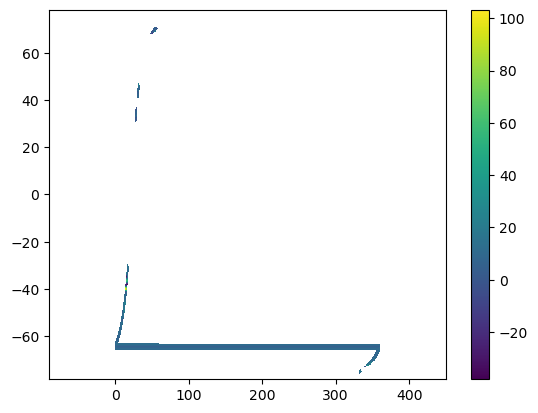

In [5]:
fig, ax = plt.subplots()
im = ax.pcolor(ds01.longitude, ds01.latitude,
          ds01.ssha_detided.isel(cycle_num=1), 
          rasterized=True
         )
fig.colorbar(im)
plt.show()

In [6]:
inp = 3

In [7]:
maskn = xr.DataArray(ds01.latitude.where(ds01.latitude>5.).to_masked_array().mask,
                     dims=ds01.latitude.dims,
                     coords=ds01.latitude.coords
                    )
masks = xr.DataArray(ds01.latitude.where(ds01.latitude<-5.).to_masked_array().mask,
                     dims=ds01.latitude.dims,
                     coords=ds01.latitude.coords
                    )
dsns = ds01.where(~maskn,drop=True)
dsns = xr.concat([dsns, ds01.where(~masks,drop=True)
                 ], "num_lines"
                ).sortby("num_lines")
dsns

<xarray.Dataset> Size: 550MB
Dimensions:       (cycle_num: 105, num_lines: 9312, num_pixels: 69)
Coordinates:
  * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
  * num_lines     (num_lines) int64 74kB 0 1 2 3 4 ... 9855 9856 9857 9858 9859
  * num_pixels    (num_pixels) int64 552B 0 1 2 3 4 5 6 ... 62 63 64 65 66 67 68
    latitude      (num_lines, num_pixels) float64 5MB dask.array<chunksize=(4656, 69), meta=np.ndarray>
    longitude     (num_lines, num_pixels) float64 5MB dask.array<chunksize=(4656, 69), meta=np.ndarray>
Data variables:
    ssha_detided  (cycle_num, num_lines, num_pixels) float64 540MB dask.array<chunksize=(1, 4656, 69), meta=np.ndarray>

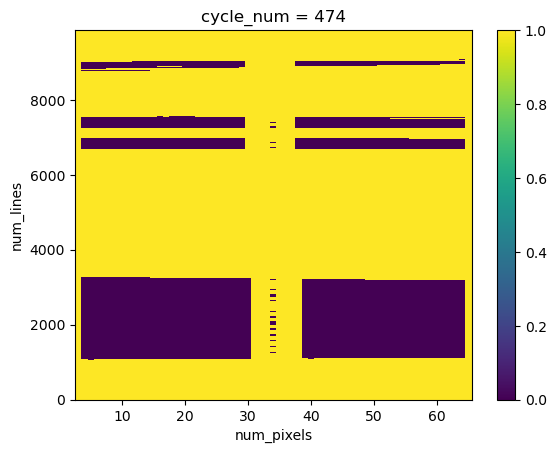

In [8]:
mask01 = xr.DataArray(dsns.ssha_detided.to_masked_array().mask.mean(axis=0), 
                     dims=dsns.ssha_detided.isel(cycle_num=0).dims, 
                     coords=dsns.ssha_detided.isel(cycle_num=0).coords
                    )
mm01 = xr.DataArray(mask01.where(mask01<.5
                              ).to_masked_array().mask,
                   dims=dsns.ssha_detided.isel(cycle_num=0).dims, 
                   coords=dsns.ssha_detided.isel(cycle_num=0).coords
                  ).isel(num_pixels=slice(inp,-inp))
mm01.plot(rasterized=True)

In [9]:
r_ref = (~mm01).sum() / np.prod(mm01.shape)
r_ref

<xarray.DataArray ()> Size: 8B
array(0.26019507)
Coordinates:
    cycle_num  int64 8B 474

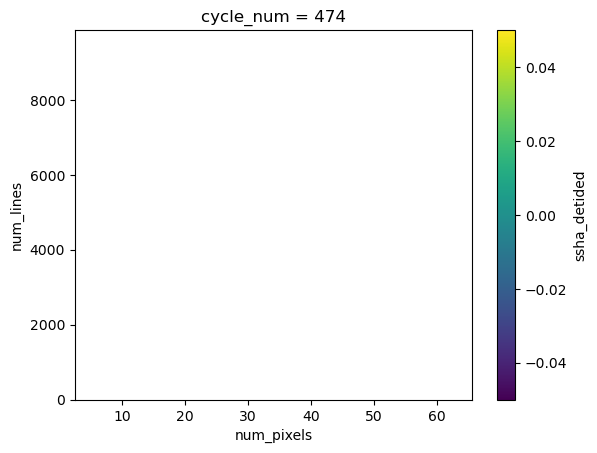

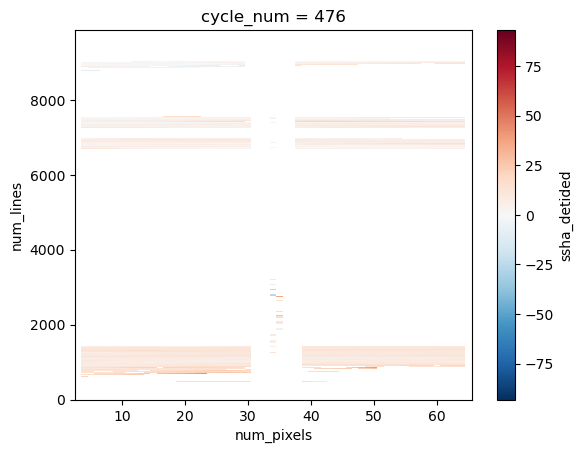

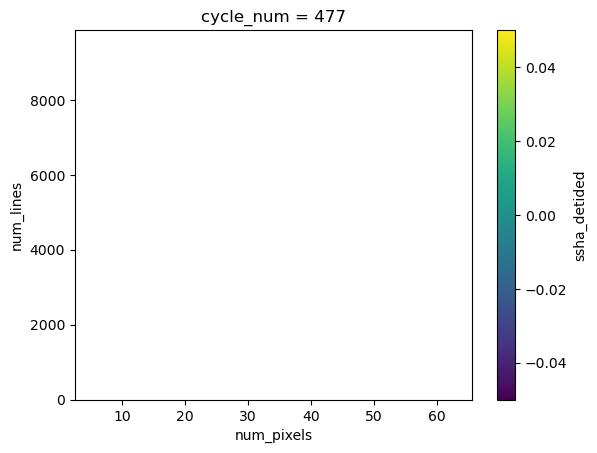

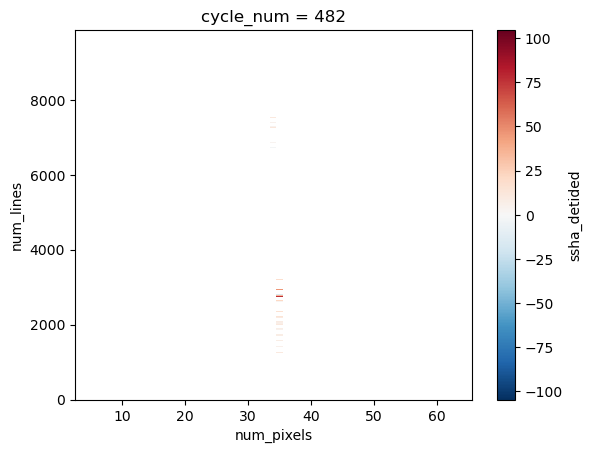

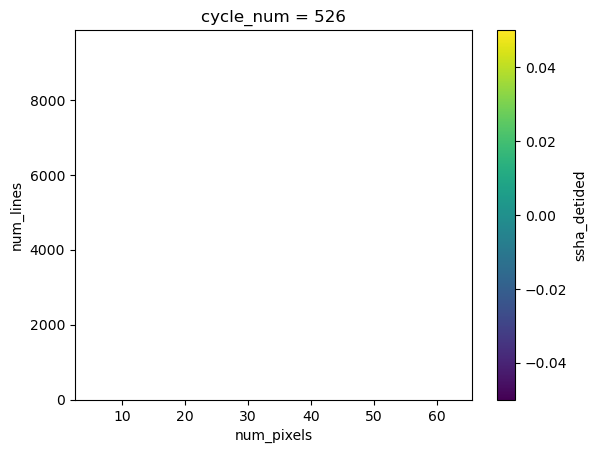

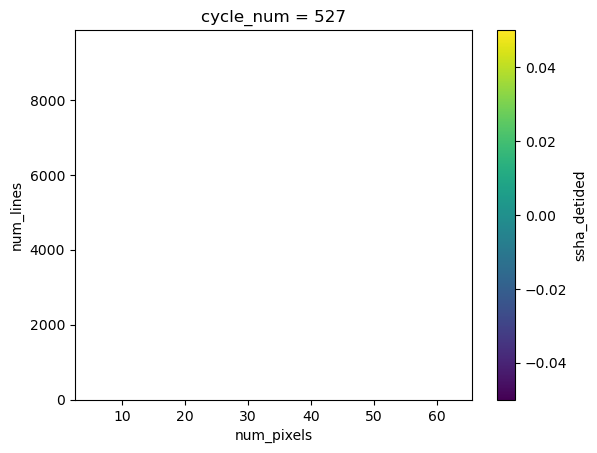

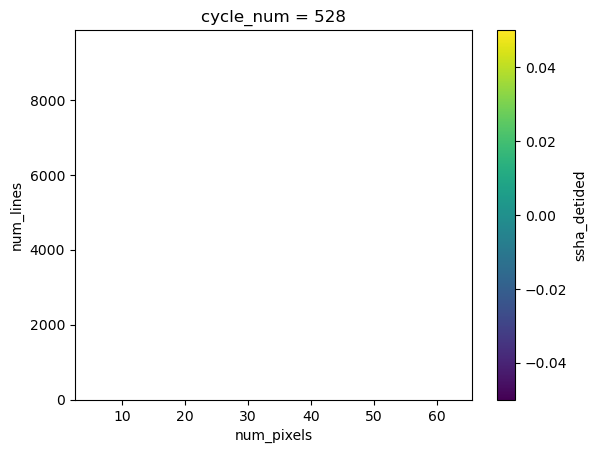

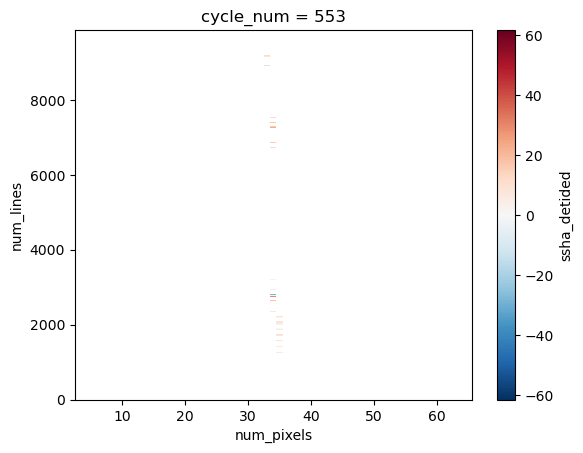

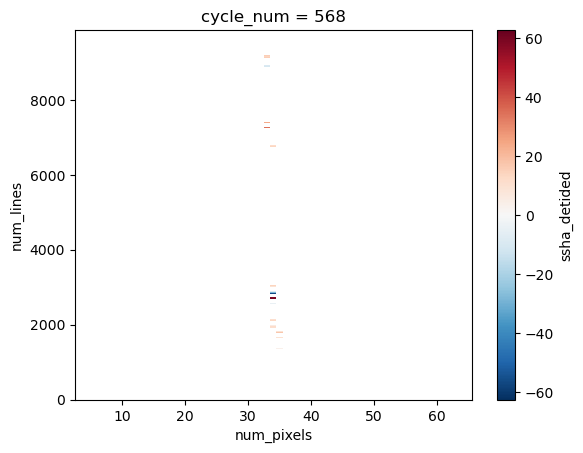

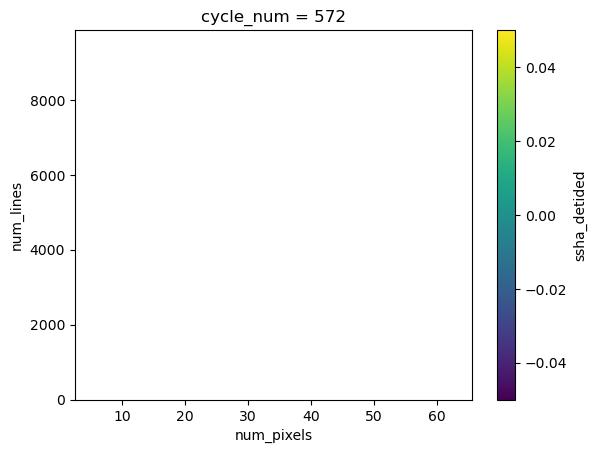

<xarray.DataArray 'ssha_detided' (cycle_num: 95, num_lines: 9312, num_pixels: 63)> Size: 446MB
dask.array<concatenate, shape=(95, 9312, 63), dtype=float64, chunksize=(1, 4656, 63), chunktype=numpy.ndarray>
Coordinates:
  * cycle_num   (cycle_num) int64 760B 475 478 479 480 481 ... 575 576 577 578
  * num_lines   (num_lines) int64 74kB 0 1 2 3 4 5 ... 9855 9856 9857 9858 9859
  * num_pixels  (num_pixels) int64 504B 3 4 5 6 7 8 9 ... 59 60 61 62 63 64 65
    latitude    (num_lines, num_pixels) float64 5MB dask.array<chunksize=(4656, 63), meta=np.ndarray>
    longitude   (num_lines, num_pixels) float64 5MB dask.array<chunksize=(4656, 63), meta=np.ndarray>

In [10]:
ic = 0
for cc in dsns.cycle_num:
    
    ssha = dsns.ssha_detided.sel(cycle_num=cc).isel(num_pixels=slice(inp,-inp))
    
    array = ssha.to_masked_array()
    mask = ~array.mask
    ratio = mask.sum() / np.prod(mask.shape)
    if ic == 0:
        R01 = xr.DataArray(np.array([ratio]), 
                           dims='cycle_num', 
                           coords={'cycle_num':np.array([cc.values,])}
                          )
    else:
        R01 = xr.concat([R01, xr.DataArray(np.array([ratio]), 
                               dims='cycle_num', 
                               coords={'cycle_num':np.array([cc.values,])}
                                          )
                        ], 'cycle_num')
    if ratio > .7*r_ref:
        if ic == 0:
            H01 = ssha
        else:
            try:
                H01 = xr.concat([H01, ssha], 'cycle_num')
            except:
                pass
        ic += 1
    else:
        ssha.plot(rasterized=True)
        plt.show()
    del ssha, mask, array

H01.coords["cycle_num"] = ("cycle_num",
                           R01.where(R01>0.7*r_ref, drop=True).cycle_num.data
                          )
H01

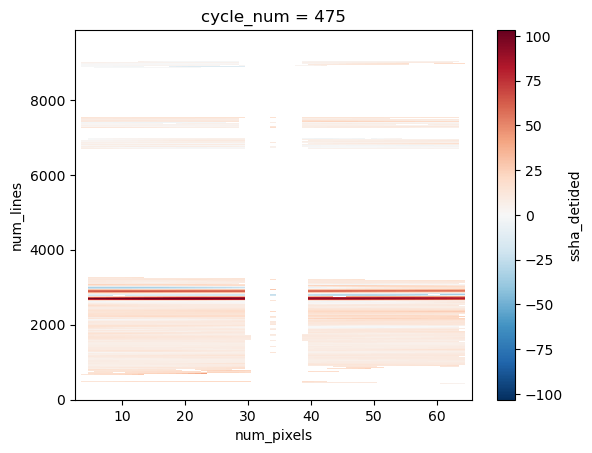

In [29]:
H01.isel(cycle_num=0).plot(rasterized=True)

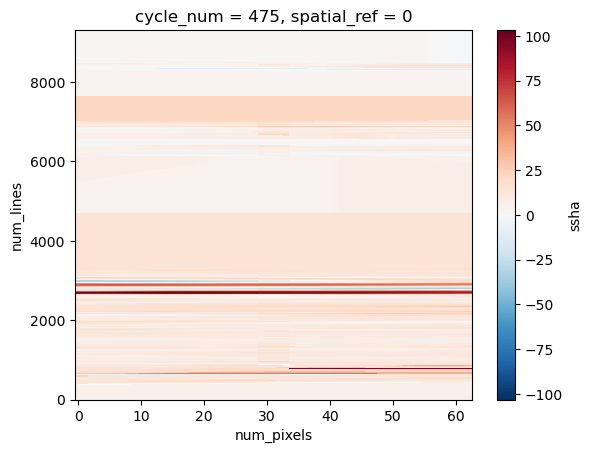

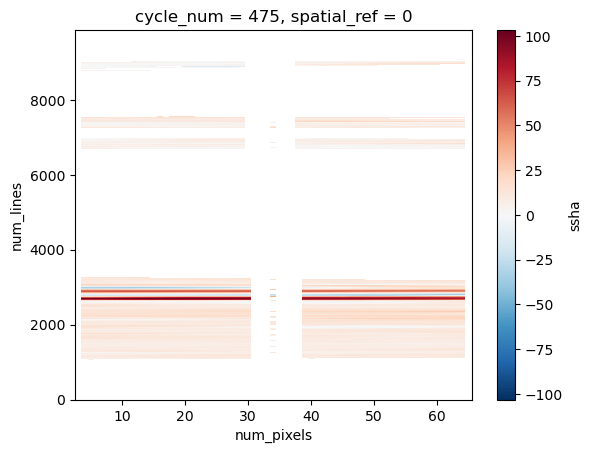

In [11]:
# for cc in H01.cycle_num:
#     _ssh = H01.sel(cycle_num=cc)

#     x1, y1 = np.meshgrid(np.arange(len(H01.num_pixels)),
#                          np.arange(len(H01.num_lines))
#                         )
    
#     array = np.ma.masked_invalid(_ssh)
#     # get only the valid values
#     _y1 = y1[~array.mask]
#     _x1 = x1[~array.mask]
#     newarr = array[~array.mask]
#     _ssh = xr.DataArray(griddata((_y1,_x1),
#                                  newarr.flatten(), 
#                                  (y1,x1), 
#                                  method=meth,
#                                        # fill_value=0.
#                                 ), 
#                         dims=H01.sel(cycle_num=cc).dims,
#                         coords=H01.sel(cycle_num=cc).coords
#                        )
#     if cc == H01.cycle_num[0]:
#         H01_interp = _ssh
#         _ssh.plot(rasterized=True)
#         plt.show()
#     else:
#         H01_interp = xr.concat([H01_interp,_ssh], "cycle_num")
    
# dsH01 = H01_interp.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
#                                                   ).reset_coords(drop=True)
dsH01 = H01.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsH01.coords["y"] = ("y",range(len(dsH01.y)))
dsH01.coords["x"] = ("x",range(len(dsH01.x)))
if not dsH01.rio.crs:
    dsH01 = dsH01.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsH01.ssha.rio.nodata is None:
    dsH01["ssha"] = dsH01.ssha.rio.write_nodata(np.nan)
_H01_exterp = dsH01.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha
_H01_exterp.isel(cycle_num=0).plot(rasterized=True)
plt.show()

H01_exterp = _H01_exterp.where(mm01!=1)
H01_exterp.isel(cycle_num=0).plot(rasterized=True)
plt.show()

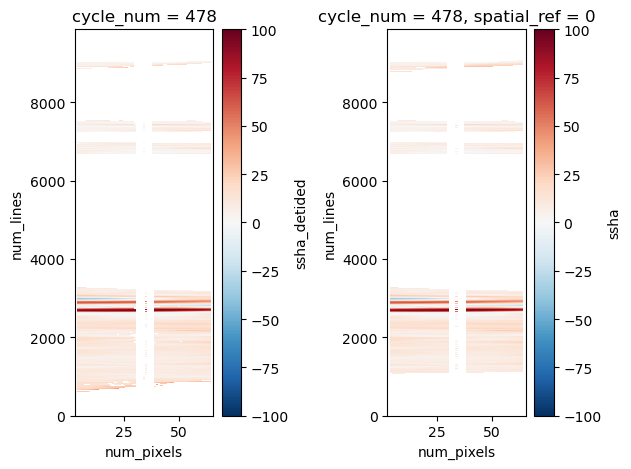

In [12]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2)
fig.set_tight_layout(True)

dsns.ssha_detided.sel(cycle_num=478
                     ).isel(num_pixels=slice(inp,-inp)
                           ).plot(ax=ax1, rasterized=True, vmax=1e2)
H01_exterp.sel(cycle_num=478).plot(ax=ax2, rasterized=True, vmax=1e2)

In [13]:
fscale = np.ceil(14/np.sqrt(12)/2)
print(fscale)

3.0


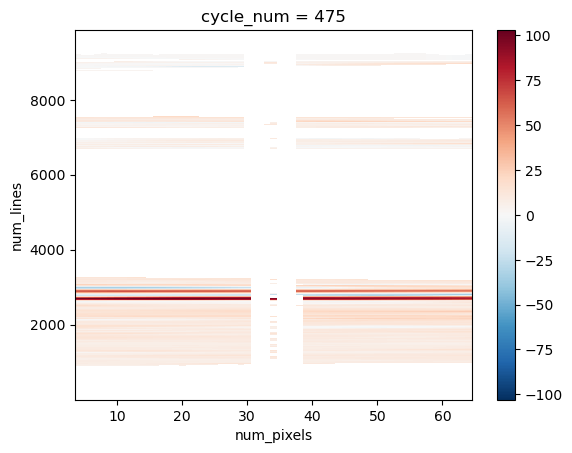

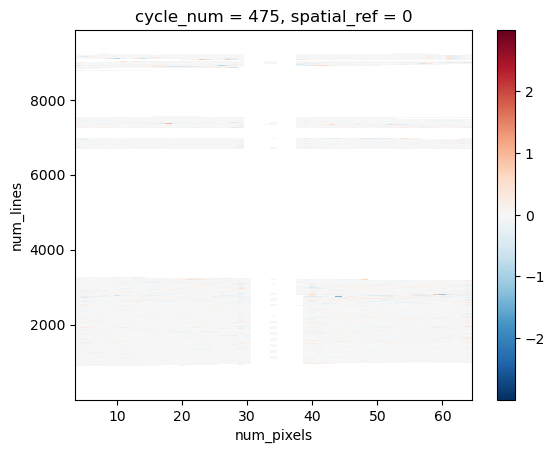

In [13]:
wet_mask = xr.DataArray(mm01.where(mm01!=0).to_masked_array().mask.astype(np.float64),
                        dims=mm01.dims, coords=mm01.coords
                       ).reset_coords(drop=True)

regular_filter = gcm_filters.Filter(
    filter_scale=fscale,
    dx_min=1,
    filter_shape=gcm_filters.FilterShape.GAUSSIAN,
    grid_type=gcm_filters.GridType.REGULAR_WITH_LAND,
    grid_vars={'wet_mask': wet_mask,
    }
)

_sshm = regular_filter.apply(_H01_exterp.chunk({'num_lines':-1,'num_pixels':-1}), 
                         dims=['num_lines','num_pixels']
                        ).reset_coords(drop=True).where(mm01!=1).chunk({"cycle_num":1,
                                                         "num_lines":-1,"num_pixels":-1}
                                                       ).isel(num_pixels=slice(1,-1),
                                                              num_lines=slice(1,-1)
                                                             )
_sshm.isel(cycle_num=0).plot()
plt.show()
(_H01_exterp.isel(num_pixels=slice(1,-1),num_lines=slice(1,-1))
 - _sshm).isel(cycle_num=0).plot()
plt.show()
dsave = _sshm.to_dataset(name="ssha"
                        ).to_zarr(op.join(ddir,
                      'CalVal/Pass%03d/ssha_rawgrid_%02dpoints.zarr' 
                      % (ipass,int(fscale))
                                         ), mode='w'
                                 )

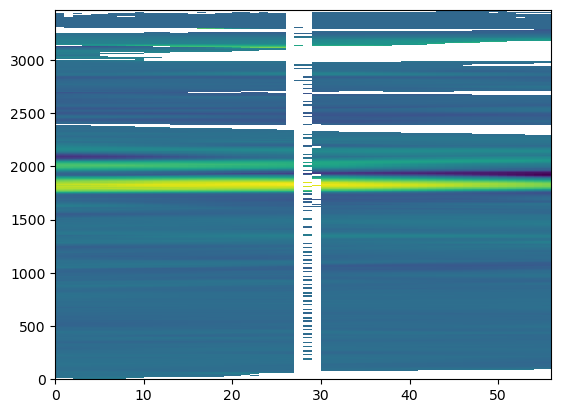

(<xarray.DataArray 'ssha' (cycle_num: 105, num_lines: 9310, num_pixels: 61)> Size: 477MB
 dask.array<mul, shape=(105, 9310, 61), dtype=float64, chunksize=(105, 847, 7), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 74kB 1 2 3 4 5 6 ... 9854 9855 9856 9857 9858
   * num_pixels  (num_pixels) int64 488B 4 5 6 7 8 9 10 ... 58 59 60 61 62 63 64
     latitude    (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9310, 61), meta=np.ndarray>
     longitude   (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9310, 61), meta=np.ndarray>,
 <xarray.DataArray 'ssha' (cycle_num: 105, num_lines: 3472, num_pixels: 56)> Size: 163MB
 dask.array<where, shape=(105, 3472, 56), dtype=float64, chunksize=(105, 846, 6), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 28kB 879 881 882 8

In [14]:
h_interp = xr.open_zarr(op.join(ddir,
                        'CalVal/Pass001/ssha_rawgrid_%02dpoints.zarr' 
                        % (fscale))
                       ).ssha.interp(cycle_num=ds01.cycle_num, 
                                     method="slinear",
                                     kwargs={"fill_value": "extrapolate"}
                                    ) * 1e-2   # centimeters to meters
# h_interp.coords["num_pixels"] = ("num_pixels", range(len(h_interp.num_pixels)))
# h_interp.coords["num_lines"] = ("num_lines", range(len(h_interp.num_lines)))
# maskh = xr.DataArray(h_interp.to_masked_array().mask,
#                      dims=h_interp.dims, coords=h_interp.coords
#                     )
h_dropped = h_interp.where(mm01.isel(num_pixels=slice(1,-1),
                                     num_lines=slice(1,-1)
                                    ).reset_coords(drop=True)!=1, drop=True)

plt.pcolormesh(h_dropped.isel(cycle_num=10).data,rasterized=True)
plt.show()
h_interp, h_dropped

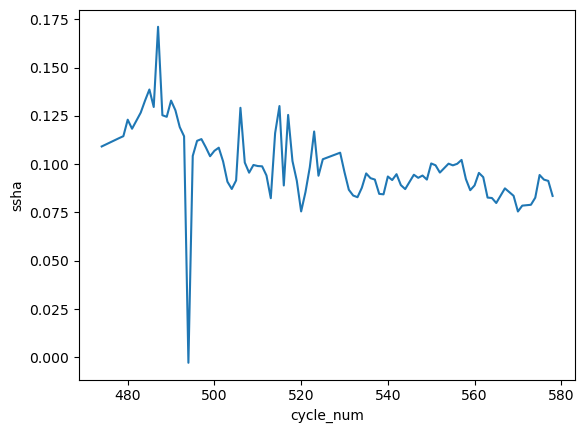

In [15]:
h_dropped.mean(['num_lines','num_pixels'],skipna=True).plot()

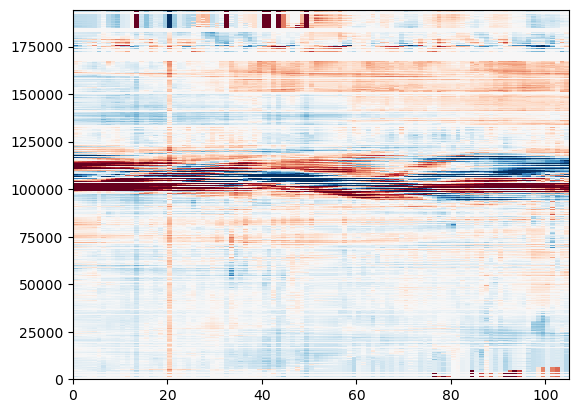

<xarray.DataArray 'ssha' (z: 194432, cycle_num: 105)> Size: 163MB
dask.array<transpose, shape=(194432, 105), dtype=float64, chunksize=(10000, 105), chunktype=numpy.ndarray>
Coordinates:
  * z           (z) object 2MB MultiIndex
  * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
    latitude    (z) float64 2MB dask.array<chunksize=(10000,), meta=np.ndarray>
    longitude   (z) float64 2MB dask.array<chunksize=(10000,), meta=np.ndarray>
  * num_lines   (z) int64 2MB 879 879 879 879 879 ... 9264 9264 9264 9264 9264
  * num_pixels  (z) int64 2MB 4 5 6 7 8 9 10 11 12 ... 57 58 59 60 61 62 63 64

In [16]:
zchunk = 10000
h_stacked = (h_dropped 
             - h_dropped.mean(['num_lines','num_pixels'],skipna=True)
            ).stack(z=('num_lines','num_pixels')
                          ).chunk({'z':zchunk}).fillna(0.)
# h_stacked = h_interp.stack(z=("YC", "XC")
#                           ).chunk({'z':zchunk}).fillna(0.)

fig, ax = plt.subplots()
ax.pcolormesh(h_stacked.T.values, 
              rasterized=True,  
              vmax=.4, vmin=-.4, cmap='RdBu_r')
plt.show()
h_stacked.T

In [17]:
nh = 24.*3600.
window_lengths = np.ceil( np.array([9, 10, 30, 60])
                         * 86400/nh ).astype(int) # 24 hourly
step_sizes = np.array([1, 1, 1, 1])
print(window_lengths, "[days]")
nh / 86400.

[ 9 10 30 60] [days]


1.0

In [19]:
fit = True

In [ ]:
svd_ranks = [4, 4, 10, 12]
if len(svd_ranks) != len(window_lengths):
    print("######### WRONG LENGTHS #########")
suppress_growth = True
transform_method = "absolute"
# n_components_array = [2] * len(window_lengths)
global_svd_array = [False] * len(window_lengths)
# kern_method = "flat"
# real_eig_limit = 0.5
# pydmd_kwargs = {
#     "eig_constraints": {"conjugate_pairs", "limited"},
#     "real_eig_limit": real_eig_limit,
# }

dmd = mrCOSTS(
    svd_rank_array=svd_ranks,
    window_length_array=window_lengths,
    step_size_array=step_sizes,
    global_svd_array=global_svd_array,
    cluster_sweep=True,
    transform_method=transform_method,
    # kern_method=kern_method,
    # relative_filter_length=relative_filter_length,
    # pydmd_kwargs=pydmd_kwargs,
)

if fit:
    dmd.fit(h_stacked.values.T, 
            np.atleast_2d(np.arange(len(h_stacked.cycle_num)
                                   ) * nh)
           )

_________________________________________________
Fitting window length = 9
0 of 97
50 of 97
Error in Global Reconstruction = 0.15
_________________________________________________
Fitting window length = 10
0 of 96
50 of 96
Error in Global Reconstruction = 0.071
_________________________________________________
Fitting window length = 30
0 of 76
50 of 76
Error in Global Reconstruction = 0.098
_________________________________________________
Fitting window length = 60
0 of 46


In [ ]:
if fit:
    # dmd.to_netcdf(op.join(ddir, 
    #                       "SWOT/CalVal/mrCOSTS_h/%02dhourly/%02d_fit"
    #                       % (nh,len(window_lengths))
    #                      )
    #              )
    dmd.to_netcdf(op.join(ddir, 
                  "CalVal/mrCOSTS/Pass%03d_%02d_raw_%02dpoints"
                  % (ipass,len(window_lengths),2)
                         )
                 )
else:
    mrc = glob.glob(op.join(ddir, 
                "CalVal/mrCOSTS/Pass%03d_04_raw_*.nc"
                % (ipass)
                           )
                   )
    print(mrc)
    dmd = mrCOSTS()
    dmd.from_netcdf(mrc)

# DMD outputs

In [18]:
dmd.multi_res_interp()
dmd._da_omega

<xarray.DataArray 'omega' (window_length: 4, window_time_means: 97, svd_rank: 12)> Size: 74kB
array([[[            nan           +nanj,
                     nan           +nanj,
          1.55297763e-06+1.88427999e-05j, ...,
                     nan           +nanj,
                     nan           +nanj,
                     nan           +nanj],
        [            nan           +nanj,
                     nan           +nanj,
          3.10213961e-07+1.83116226e-05j, ...,
                     nan           +nanj,
                     nan           +nanj,
                     nan           +nanj],
        [            nan           +nanj,
                     nan           +nanj,
          2.38722565e-07+1.80323366e-05j, ...,
                     nan           +nanj,
                     nan           +nanj,
                     nan           +nanj],
        ...,
        [            nan           +nanj,
...
                     nan           +nanj],
        ...,
        [            nan           +nanj,
                     nan           +nanj,
                     nan           +nanj, ...,
                     nan           +nanj,
                     nan           +nanj,
                     nan           +nanj],
        [            nan           +nanj,
                     nan           +nanj,
                     nan           +nanj, ...,
                     nan           +nanj,
                     nan           +nanj,
                     nan           +nanj],
        [            nan           +nanj,
                     nan           +nanj,
                     nan           +nanj, ...,
                     nan           +nanj,
                     nan           +nanj,
                     nan           +nanj]]], shape=(4, 97, 12))
Coordinates:
  * window_length        (window_length) int64 32B 9 10 30 60
  * window_time_means    (window_time_means) float64 776B 3.456e+05 ... 8.64e+06
  * svd_rank             (svd_rank) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
    slide                (window_length, window_time_means) float64 3kB 0.0 ....
    decomposition_level  (window_length) int64 32B 0 1 2 3

fitting n_components = 4
fitting n_components = 5
fitting n_components = 6
fitting n_components = 7
fitting n_components = 8
fitting n_components = 9
fitting n_components = 10
fitting n_components = 11
fitting n_components = 12
fitting n_components = 13
fitting n_components = 14
fitting n_components = 15
fitting n_components = 16
fitting n_components = 17
fitting n_components = 18
fitting n_components = 19
fitting n_components = 20
fitting n_components = 21
fitting n_components = 22
fitting n_components = 23
fitting n_components = 24
fitting n_components = 25
fitting n_components = 26
fitting n_components = 27
fitting n_components = 28
fitting n_components = 29
Optimal silhouette score is = 8


Text(0, 0.5, 'Silhouette score (-), (1 is best, -1 is worst)')

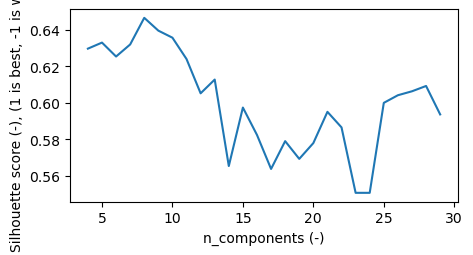

In [19]:
n_components_range = np.arange(4, 30)
scores, n_optimal = dmd.global_cluster_hyperparameter_sweep(
    n_components_range,
    transform_method="log10",
)

print("Optimal silhouette score is = {}".format(n_optimal))
plt.figure(figsize=(5, 2.5))
plt.plot(n_components_range, scores)
plt.gca().set_xlabel("n_components (-)")
plt.gca().set_ylabel("Silhouette score (-), (1 is best, -1 is worst)")

In [20]:
# n_ops = 10
cluster_centroids, omega_classes, omega_array = dmd.global_cluster_omega(
    n_optimal,
    # n_ops,
    transform_method="log10"
)
cluster_centers_periods = 1 / (10 ** (cluster_centroids) / (2 * np.pi))

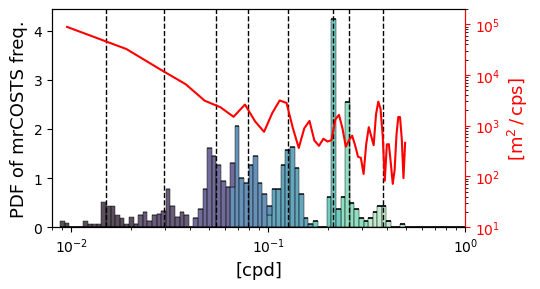

In [21]:
x_trans = (2 * np.pi / 10**omega_array / 86400.)**-1

hue_order = np.arange(len(np.unique(omega_classes))).astype(str)
cluster_centers = 1 / ((10 ** cluster_centroids) / (2 * np.pi) / 86400.)

# Make a continuous color palette with the brightest and darkest excluded
palette = sns.color_palette("mako", len(cluster_centers) + 2)
# palette = palette[1:-1]


Fh = xrft.power_spectrum(h_dropped[...,::150,10::40
                         ].chunk({'cycle_num':-1}
                                ).assign_coords({'cycle_num':
                                                 np.arange(len(h_interp.cycle_num)) 
                                                 * nh}
                                               ), 
                         dim='cycle_num', window='hann', window_correction=True
                        ).astype(np.single)

from matplotlib.colors import ListedColormap

fig, ax = plt.subplots(figsize=(5.5, 3))
ax2 = ax.twinx()
fig.set_tight_layout(True)

ax2.plot(Fh.freq_cycle_num.isel(freq_cycle_num=slice(len(Fh.freq_cycle_num)//2+1,None)
                               )*86400, 
         Fh.isel(freq_cycle_num=slice(len(Fh.freq_cycle_num)//2+1,None)
                ).mean(['num_pixels','num_lines'],skipna=True)*2,
         c='r', label=r"Fourier")

ax.set_xscale("log")
ax2.set_yscale("log")

sns.histplot(
    # x=((10**omega_array) / (2 * np.pi) / 86400.),
    x=x_trans,
    hue=omega_classes,
    hue_order=hue_order,
    common_bins=True,
    common_norm=True,
    stat="density",
    multiple="stack",
    bins=90,
    palette=ListedColormap(palette),
    legend=False,
    ax=ax
)

ax.set_xlabel(r"[cpd]", fontsize=13)
ax.set_ylabel("PDF of mrCOSTS freq.", fontsize=13)
ax2.set_ylabel("[m$^2\,/\,$cps]", fontsize=13, c='r')

ax.set_xlim([8e-3,1e0])
# ax2.set_xlim([8e-3,1.5e1])
ax2.set_ylim([1e1,2e5])

ax2.spines['right'].set_color('red')
ax2.tick_params(axis='y', colors='red')

[
    ax.axvline((2 * np.pi / (10**c) / 86400)**-1, color="k", ls="--", lw=1)
    for nc, c in enumerate(cluster_centroids)
];

plt.savefig(op.join(ddir,'Figs/SWOT_Pass%03d-raw_mrCOSTS_hist-%02d_%02dpoints.pdf' 
                    % (ipass,len(window_lengths),int(fscale)))
           )

In [22]:
np.where((2 * np.pi / (10**cluster_centroids) 
          / 86400)**-1 <= 1e-1)

(array([0, 1, 2, 3]),)

In [23]:
omega_classes_list = dmd.multi_res_deterp()

In [25]:
xr_background = dmd.get_background()
print(xr_background.shape, h_stacked)

ds_global_background = xr.DataArray(xr_background, dims=h_stacked.T.dims,
                            coords=h_stacked.T.coords
                           ).unstack().chunk({'cycle_num':1}
                                            ).interp(
    num_pixels=mm01.drop("cycle_num").isel(num_pixels=slice(1,-1)).num_pixels,
    num_lines=mm01.drop("cycle_num").isel(num_lines=slice(1,-1)).num_lines
                                            ).where(mm01.isel(num_pixels=slice(1,-1),
                                                              num_lines=slice(1,-1)
                                                             )!=1
                                                   )
ds_global_background.chunk(
        {'num_pixels':-1, 'num_lines':-1}
).to_dataset(name='background'
            ).to_zarr(op.join(ddir,
            'CalVal/Pass%03d/background-raw_%02dpoints.zarr' 
                              % (ipass, fscale)),
                              mode='w')

(194432, 105) <xarray.DataArray 'ssha' (cycle_num: 105, z: 194432)> Size: 163MB
dask.array<where, shape=(105, 194432), dtype=float64, chunksize=(105, 10000), chunktype=numpy.ndarray>
Coordinates:
  * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
  * z           (z) object 2MB MultiIndex
    latitude    (z) float64 2MB dask.array<chunksize=(10000,), meta=np.ndarray>
    longitude   (z) float64 2MB dask.array<chunksize=(10000,), meta=np.ndarray>
  * num_lines   (z) int64 2MB 879 879 879 879 879 ... 9264 9264 9264 9264 9264
  * num_pixels  (z) int64 2MB 4 5 6 7 8 9 10 11 12 ... 57 58 59 60 61 62 63 64


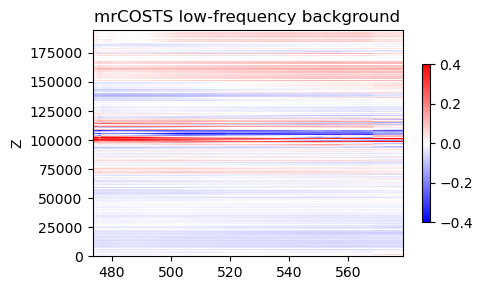

In [26]:
fig, ax = plt.subplots(figsize=(5, 3))
fig.set_tight_layout(True)
im = ax.pcolormesh(
    h_stacked.cycle_num,
    np.arange(len(h_stacked.z)), 
    xr_background, 
    vmin=-.4, vmax=.4, cmap="bwr",
    rasterized=True
)
ax.set_title("mrCOSTS low-frequency background")
ax.set_ylabel("Z")
# fig.autofmt_xdate()
fig.colorbar(im, shrink=.7)

In [27]:
xr_sep = dmd.global_scale_reconstruction()

In [28]:
for ncl_center, cl_center in enumerate(cluster_centers_periods):
    
    ds_xr_sep = xr.DataArray(
        xr_sep.real[:, ncl_center],
        dims=["decomp_level", "z", "cycle_num"],
        coords=[
            np.arange(len(dmd.costs_array)),
            # np.arange(n_optimal),
            h_stacked.z,
            h_stacked.cycle_num,
        ],
    )
    
    for dd in ds_xr_sep.decomp_level:
        if dd == 0:
            sep_unstacked = ds_xr_sep.sel(decomp_level=dd
                                 ).unstack().chunk({'cycle_num':1})
        else:
            tmp = ds_xr_sep.sel(decomp_level=dd
                               ).unstack().chunk({'cycle_num':1})
            sep_unstacked = xr.concat([sep_unstacked,
                                       tmp
                                      ], 'decomp_level'
                                     )
            del tmp

    ds_global_separation = sep_unstacked.interp(
        num_pixels=mm01.drop("cycle_num").isel(num_pixels=slice(1,-1)).num_pixels,
        num_lines=mm01.drop("cycle_num").isel(num_lines=slice(1,-1)).num_lines
                                               ).where(mm01.isel(num_pixels=slice(1,-1),
                                                                 num_lines=slice(1,-1)
                                                                )!=1
                                                      )

    ds_cluster_centers = xr.DataArray(
        np.array([1 / (10 ** (cluster_centroids[ncl_center]) / (2 * np.pi)),]),
        dims=["cluster"],
        # coords=[np.arange(n_optimal)],
        coords=[np.array([ncl_center,])],
    )
    ds_cluster_centers.attrs["units"] = "s"
    ds_cluster_centers.attrs["long_name"] = "Central period of each period band"
    
    ds_global_separation = ds_global_separation.to_dataset(name="frequency_bands")
    ds_global_separation["frequency_bands"].attrs["units"] = "m"
    ds_global_separation["frequency_bands"].attrs["long_name"] = "mrCOSTS"
    
    ds_global_separation.coords["cluster_centers"] = ds_cluster_centers

    if ncl_center == 0:
        print(ds_global_separation)
        
    ds_global_separation.chunk(
                {'num_pixels':-1, 'num_lines':-1}
                ).to_zarr(op.join(ddir,
    'CalVal/Pass%03d/cluster%02d-raw_%02dpoints.zarr' 
                      % (ipass, ncl_center, fscale)),
                      mode='w')
    print(ncl_center)

<xarray.Dataset> Size: 2GB
Dimensions:          (decomp_level: 4, cycle_num: 105, num_pixels: 61,
                      num_lines: 9310, cluster: 1)
Coordinates:
  * decomp_level     (decomp_level) int64 32B 0 1 2 3
  * cycle_num        (cycle_num) int64 840B 474 475 476 477 ... 575 576 577 578
  * num_pixels       (num_pixels) int64 488B 4 5 6 7 8 9 ... 59 60 61 62 63 64
  * num_lines        (num_lines) int64 74kB 1 2 3 4 5 ... 9855 9856 9857 9858
  * cluster          (cluster) int64 8B 0
    latitude         (num_lines, num_pixels) float64 5MB dask.array<chunksize=(4655, 61), meta=np.ndarray>
    longitude        (num_lines, num_pixels) float64 5MB dask.array<chunksize=(4655, 61), meta=np.ndarray>
    cluster_centers  (cluster) float64 8B 5.727e+06
Data variables:
    frequency_bands  (decomp_level, cycle_num, num_lines, num_pixels) float64 2GB dask.array<chunksize=(1, 1, 9310, 61), meta=np.ndarray>
0
1
2
3
4
5
6
7


In [29]:
xr_global_reconstruction = dmd.global_reconstruction()
glb_unstacked = xr.DataArray(
    data=xr_global_reconstruction.real, 
    dims=h_stacked.T.dims,
    coords=h_stacked.T.coords
).unstack()

da_global_reconstruction = glb_unstacked.interp(
        num_pixels=mm01.drop("cycle_num").isel(num_pixels=slice(1,-1)).num_pixels,
        num_lines=mm01.drop("cycle_num").isel(num_lines=slice(1,-1)).num_lines
                                               ).where(mm01.isel(num_pixels=slice(1,-1),
                                                                 num_lines=slice(1,-1)
                                                                )!=1
                                                      )
da_global_reconstruction.attrs["units"] = "m"
da_global_reconstruction.attrs["long_name"] = r"SWOT SSH"

da_global_reconstruction.chunk(
    # {'lat':100, 'lon':100}
).to_dataset(name='SSH').to_zarr(op.join(ddir,
                    'CalVal/Pass%03d/Total-raw_%02dpoints.zarr' 
                      % (ipass, fscale)),
                      mode='w')

# Extract slow component

In [32]:
for i in range(30):
    if i == 0:
        dsc = xr.open_zarr(op.join(ddir,
                    'CalVal/Pass%03d/cluster%02d-raw_%02dpoints.zarr' 
                                    % (ipass,i,fscale))
                           )

    else:
        try:
            dsc = xr.concat([dsc,xr.open_zarr(op.join(ddir,
                    'CalVal/Pass%03d/cluster%02d-raw_%02dpoints.zarr' 
                                  % (ipass,i,fscale)))
                            ], 'cluster')

        except:
            pass
    
dsC = xr.open_zarr(op.join(ddir,
            'CalVal/Pass%03d/Total-raw_%02dpoints.zarr' 
                           % (ipass,fscale))
                  )

dsb = xr.open_zarr(op.join(ddir,
            'CalVal/Pass%03d/background-raw_%02dpoints.zarr' 
                           % (ipass,fscale))
                  )

dsc

<xarray.Dataset> Size: 15GB
Dimensions:          (cluster: 8, decomp_level: 4, cycle_num: 105,
                      num_lines: 9310, num_pixels: 61)
Coordinates:
  * cluster          (cluster) int64 64B 0 1 2 3 4 5 6 7
  * decomp_level     (decomp_level) int64 32B 0 1 2 3
  * cycle_num        (cycle_num) int64 840B 474 475 476 477 ... 575 576 577 578
  * num_lines        (num_lines) int64 74kB 1 2 3 4 5 ... 9855 9856 9857 9858
  * num_pixels       (num_pixels) int64 488B 4 5 6 7 8 9 ... 59 60 61 62 63 64
    cluster_centers  (cluster) float64 64B dask.array<chunksize=(1,), meta=np.ndarray>
    latitude         (num_lines, num_pixels) float64 5MB -77.13 -77.14 ... 77.13
    longitude        (num_lines, num_pixels) float64 5MB 299.0 299.0 ... 105.8
Data variables:
    frequency_bands  (cluster, decomp_level, cycle_num, num_lines, num_pixels) float64 15GB dask.array<chunksize=(1, 1, 1, 9310, 61), meta=np.ndarray>

In [33]:
n_cluster = len(np.where((2 * np.pi / (10**cluster_centroids) 
                          / 86400.)**-1 <= 1e-1)[0])
print(n_cluster)
low = (dsb.background 
       + dsc.frequency_bands.isel(cluster=slice(None,n_cluster)
                                 ).sum(['cluster','decomp_level'])
      )

tot = xr.open_zarr(op.join(ddir,
                       'CalVal/Pass%03d/Total-raw_%02dpoints.zarr' 
                       % (ipass,fscale))
                  ).SSH

low

4


<xarray.DataArray (cycle_num: 105, num_lines: 9310, num_pixels: 61)> Size: 477MB
dask.array<add, shape=(105, 9310, 61), dtype=float64, chunksize=(1, 9310, 61), chunktype=numpy.ndarray>
Coordinates:
  * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
  * num_lines   (num_lines) int64 74kB 1 2 3 4 5 6 ... 9854 9855 9856 9857 9858
  * num_pixels  (num_pixels) int64 488B 4 5 6 7 8 9 10 ... 58 59 60 61 62 63 64
    latitude    (num_lines, num_pixels) float64 5MB -77.13 -77.14 ... 77.13
    longitude   (num_lines, num_pixels) float64 5MB 299.0 299.0 ... 105.8 105.8

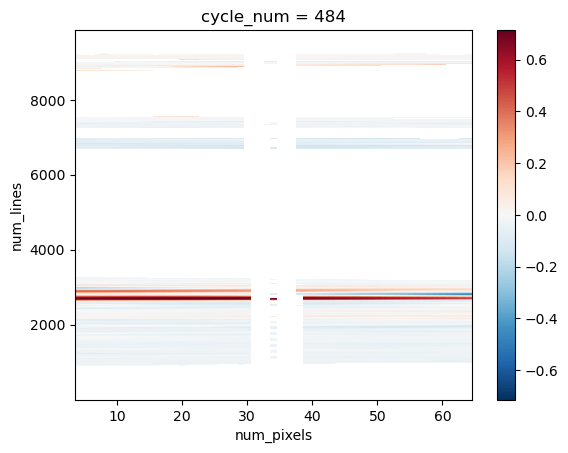

In [34]:
low.isel(cycle_num=10).plot(rasterized=True)